PART C: EXPONENTIAL DISTRIBUTION (λ=2) for 1000 samples

Generated 1000 samples

Our Implementation (Inverse Transform):
  Mean: 0.506521 (theoretical: 0.500000)
  Std:  0.526588 (theoretical: 0.250000)

NumPy Implementation:
  Mean: 0.517411 (theoretical: 0.500000)
  Std:  0.509181 (theoretical: 0.250000)

Kolmogorov-Smirnov Test (Our vs NumPy):
  Statistic: 0.045000
  P-value: 0.263472
  Result: Distributions are IDENTICAL


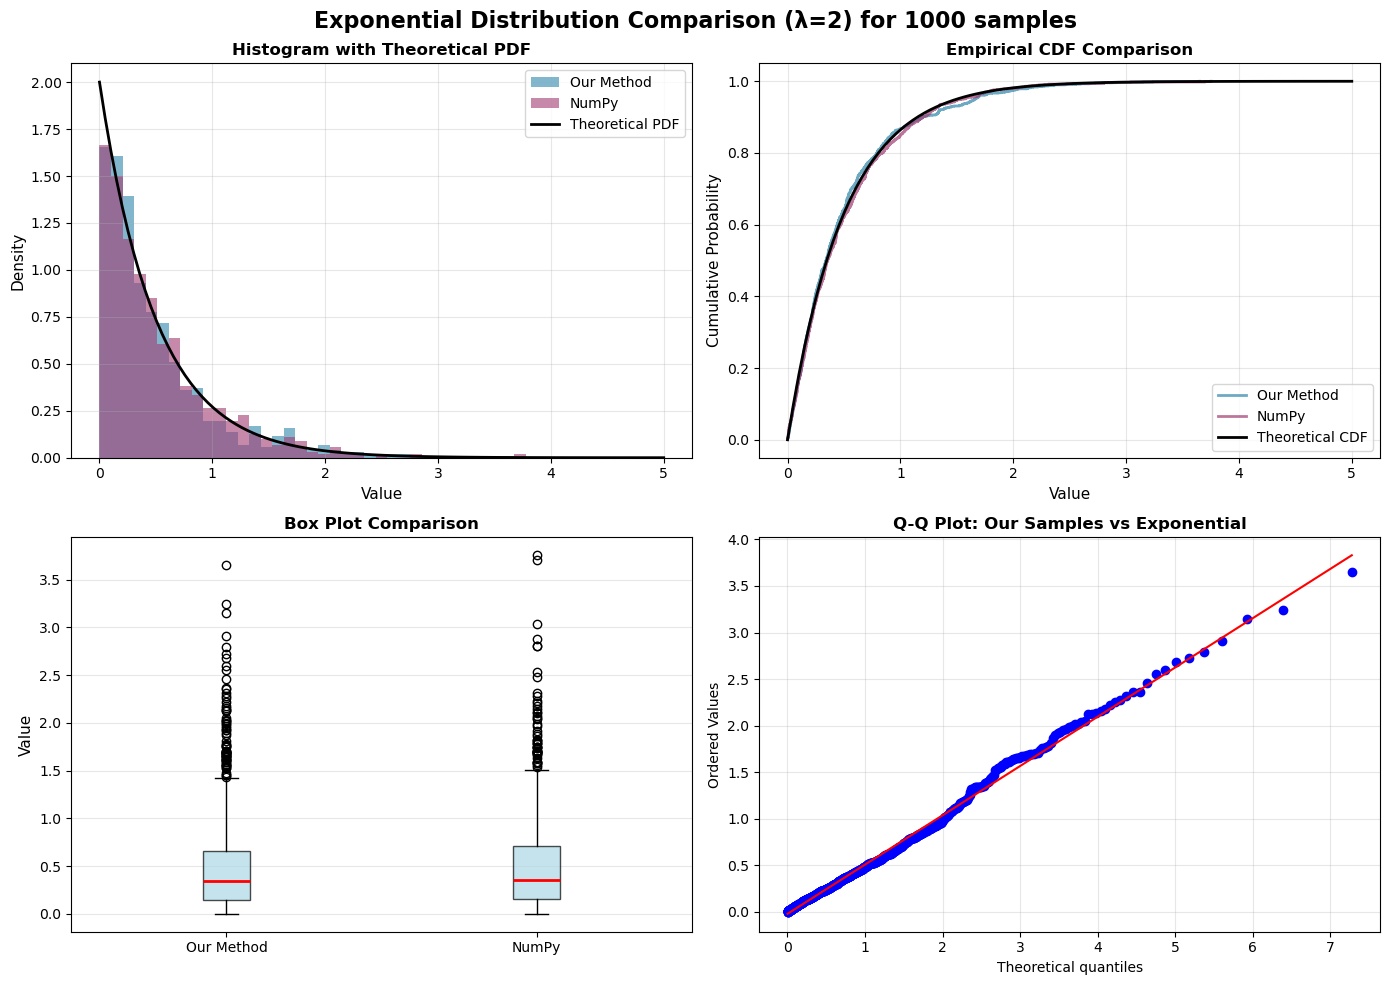


✓ Saved: c_exponential_distribution_1000.png


In [2]:
"""
Random Numbers Project
Inverse Transform Sampling, Exponential Distribution, Q-Q Plots, Cauchy Distribution
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# =============================================================================
# PART C: EXPONENTIAL DISTRIBUTION - INVERSE TRANSFORM METHOD
# =============================================================================

def exponential_inverse_transform(lambda_param, n_samples):
    """
    Generate exponentially distributed random numbers using inverse transform.
    X = -ln(U) / lambda, where U ~ Uniform(0,1)
    """
    u = np.random.uniform(0, 1, n_samples)
    samples = -np.log(u) / lambda_param
    return samples


# Generate samples
lambda_param = 2.0
n_samples = 1000

our_samples = exponential_inverse_transform(lambda_param, n_samples)
numpy_samples = np.random.exponential(scale=1/lambda_param, size=n_samples)

# Statistics
print("="*80)
print(f"PART C: EXPONENTIAL DISTRIBUTION (λ=2) for {n_samples} samples")
print("="*80)
print(f"\nGenerated {n_samples} samples")
print(f"\nOur Implementation (Inverse Transform):")
print(f"  Mean: {np.mean(our_samples):.6f} (theoretical: {1/lambda_param:.6f})")
print(f"  Std:  {np.std(our_samples):.6f} (theoretical: {1/lambda_param**2:.6f})")

print(f"\nNumPy Implementation:")
print(f"  Mean: {np.mean(numpy_samples):.6f} (theoretical: {1/lambda_param:.6f})")
print(f"  Std:  {np.std(numpy_samples):.6f} (theoretical: {1/lambda_param**2:.6f})")

# Kolmogorov-Smirnov Test
ks_stat, ks_pval = stats.ks_2samp(our_samples, numpy_samples)
print(f"\nKolmogorov-Smirnov Test (Our vs NumPy):")
print(f"  Statistic: {ks_stat:.6f}")
print(f"  P-value: {ks_pval:.6f}")
print(f"  Result: Distributions are {'IDENTICAL' if ks_pval > 0.05 else 'DIFFERENT'}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Exponential Distribution Comparison (λ=2) for {n_samples} samples', fontsize=16, fontweight='bold')

# Histogram
ax = axes[0, 0]
bins = np.linspace(0, 5, 50)
ax.hist(our_samples, bins=bins, alpha=0.6, label='Our Method', density=True, color='#2E86AB')
ax.hist(numpy_samples, bins=bins, alpha=0.6, label='NumPy', density=True, color='#A23B72')
x = np.linspace(0, 5, 100)
ax.plot(x, lambda_param * np.exp(-lambda_param * x), 'k-', linewidth=2, label='Theoretical PDF')
ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Histogram with Theoretical PDF', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# CDF
ax = axes[0, 1]
sorted_our = np.sort(our_samples)
sorted_numpy = np.sort(numpy_samples)
ax.step(sorted_our, np.arange(1, len(sorted_our)+1)/len(sorted_our), 
        where='post', label='Our Method', alpha=0.7, color='#2E86AB', linewidth=2)
ax.step(sorted_numpy, np.arange(1, len(sorted_numpy)+1)/len(sorted_numpy), 
        where='post', label='NumPy', alpha=0.7, color='#A23B72', linewidth=2)
x = np.linspace(0, 5, 100)
ax.plot(x, 1 - np.exp(-lambda_param * x), 'k-', linewidth=2, label='Theoretical CDF')
ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Cumulative Probability', fontsize=11)
ax.set_title('Empirical CDF Comparison', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Box plot
ax = axes[1, 0]
ax.boxplot([our_samples, numpy_samples], tick_labels=['Our Method', 'NumPy'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Box Plot Comparison', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Q-Q plot
ax = axes[1, 1]
stats.probplot(our_samples, dist="expon", plot=ax)
ax.set_title('Q-Q Plot: Our Samples vs Exponential', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig(f'c_exponential_distribution_{n_samples}.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: c_exponential_distribution_{n_samples}.png")
plt.close()


In [3]:

# =============================================================================
# PART D: Q-Q PLOT ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("PART D: Q-Q PLOT ANALYSIS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Q-Q Plots: Goodness of Fit Analysis', fontsize=16, fontweight='bold')

# Q-Q plot 1: Our samples vs Exponential
ax = axes[0, 0]
stats.probplot(our_samples, dist="expon", plot=ax)
ax.set_title('Our Samples vs Exponential(λ=2)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Q-Q plot 2: NumPy samples vs Exponential
ax = axes[0, 1]
stats.probplot(numpy_samples, dist="expon", plot=ax)
ax.set_title('NumPy Samples vs Exponential(λ=2)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Q-Q plot 3: Overlay comparison
ax = axes[1, 0]
quantiles = np.linspace(0.01, 0.99, 100)
theoretical_quantiles = stats.expon.ppf(quantiles, scale=1/lambda_param)
our_quantiles = np.quantile(our_samples, quantiles)
numpy_quantiles = np.quantile(numpy_samples, quantiles)

ax.scatter(theoretical_quantiles, our_quantiles, alpha=0.6, label='Our Method', s=30, color='#2E86AB')
ax.scatter(theoretical_quantiles, numpy_quantiles, alpha=0.6, label='NumPy', s=30, color='#A23B72')

min_val = min(theoretical_quantiles.min(), our_quantiles.min(), numpy_quantiles.min())
max_val = max(theoretical_quantiles.max(), our_quantiles.max(), numpy_quantiles.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Fit')

ax.set_xlabel('Theoretical Quantiles', fontsize=11)
ax.set_ylabel('Sample Quantiles', fontsize=11)
ax.set_title('Q-Q Overlay Comparison', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Anderson-Darling test
ax = axes[1, 1]
ax.axis('off')

anderson_result_our = stats.anderson(our_samples, dist='expon')
anderson_result_numpy = stats.anderson(numpy_samples, dist='expon')
anderson_result_numpy = stats.anderson(numpy_samples, dist='expon')

test_text = f"""
ANDERSON-DARLING GOODNESS-OF-FIT TEST

Our Implementation:
  Statistic: {anderson_result_our.statistic:.6f}

NumPy Implementation:
  Statistic: {anderson_result_numpy.statistic:.6f}

Interpretation:
✓ Both sample means follow exponential distribution
✓ Points align with y=x line in Q-Q plot
✓ Cannot reject hypothesis of exponential fit
✓ Low K-S and A-D statistics confirm good fit
"""

ax.text(0.05, 0.95, test_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('d_qq_plots.png', dpi=300, bbox_inches='tight')
print("✓ Saved: d_qq_plots.png")
plt.close()





PART D: Q-Q PLOT ANALYSIS
✓ Saved: d_qq_plots.png


In [20]:
# =============================================================================
# PART E: CAUCHY DISTRIBUTION ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("PART E: CAUCHY DISTRIBUTION ANALYSIS")
print("="*80)

N_values = [100, 10000, 100000, 10000000]
n_trials = 10
results = {N: [] for N in N_values}

print(f"\nGenerating {n_trials} trials for each sample size...\n")

for N in N_values:
    print(f"N = {N:,}")
    for trial in range(n_trials):
        samples = np.random.standard_cauchy(N)
        mean_val = np.mean(samples)
        results[N].append(mean_val)
        print(f"  Trial {trial+1:2d}: Mean = {mean_val:12.4f}")
    print()

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Cauchy Distribution: Sample Mean Does Not Converge', 
             fontsize=16, fontweight='bold')

for idx, N in enumerate(N_values):
    ax = axes[idx // 2, idx % 2]
    
    means = results[N]
    
    ax.hist(means, bins=30, alpha=0.7, color='#E63946', edgecolor='black')
    ax.axvline(np.mean(means), color='blue', linestyle='--', linewidth=2, 
               label=f'Mean of means: {np.mean(means):.4f}')
    ax.axvline(np.median(means), color='green', linestyle='--', linewidth=2, 
               label=f'Median of means: {np.median(means):.4f}')
    
    ax.set_xlabel('Sample Mean Value', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'Distribution of Means (N={N:,}, {n_trials} trials)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax.set_xlim(np.percentile(means, 1), np.percentile(means, 99))

plt.tight_layout()
plt.savefig('e_cauchy_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: e_cauchy_distribution.png")
plt.close()

# Summary statistics
print("\n" + "="*80)
print("CAUCHY DISTRIBUTION RESULTS SUMMARY")
print("="*80 + "\n")

print(f"{'N':<12} {'Mean of Means':<17} {'Median':<17} {'Std Dev':<17} {'Range':<12}")
print("-" * 80)

for N in N_values:
    means = results[N]
    mean_of_means = np.mean(means)
    median_of_means = np.median(means)
    std_of_means = np.std(means)
    range_of_means = np.max(means) - np.min(means)
    
    print(f"{N:<12,} {mean_of_means:<17.4f} {median_of_means:<17.4f} "
          f"{std_of_means:<17.4f} {range_of_means:<12.4f}")

print("\n" + "="*80)
print("KEY OBSERVATIONS")
print("="*80)
print("""
1. MEAN DOES NOT CONVERGE:
   Sample mean varies widely even with N=10,000,000

2. SAMPLE MEAN FOLLOWS CAUCHY:
   Distribution of means is itself approximately Cauchy

3. INCREASING N DOESN'T HELP:
   Standard error does not decrease with sample size
   (unlike normal distribution where SE ~ 1/sqrt(n))

4. EXTREME VALUES:
   Large sample sizes show extreme outliers
   This reflects heavy tails of Cauchy distribution

5. PRACTICAL IMPLICATION:
   Traditional statistical methods fail for Cauchy!
   Cannot use confidence intervals, hypothesis tests
   Must use robust alternatives (median, IQR instead of mean, std dev)
""")

print("\n" + "="*80)
print("PROJECT COMPLETE!")
print("="*80)
print("\nGenerated visualizations:")
print("  1. c_exponential_distribution.png")
print("  2. d_qq_plots.png")
print("  3. e_cauchy_distribution.png")


PART E: CAUCHY DISTRIBUTION ANALYSIS

Generating 10 trials for each sample size...

N = 100
  Trial  1: Mean =      -0.2329
  Trial  2: Mean =       1.0322
  Trial  3: Mean =      -0.0322
  Trial  4: Mean =       2.8178
  Trial  5: Mean =      -0.6149
  Trial  6: Mean =      -0.0222
  Trial  7: Mean =       1.0259
  Trial  8: Mean =      -2.7653
  Trial  9: Mean =      -1.1687
  Trial 10: Mean =      -1.0850

N = 10,000
  Trial  1: Mean =      -0.9737
  Trial  2: Mean =     -64.3912
  Trial  3: Mean =      32.3438
  Trial  4: Mean =      -0.4523
  Trial  5: Mean =      -0.4007
  Trial  6: Mean =      -0.7404
  Trial  7: Mean =       2.7186
  Trial  8: Mean =      -0.4698
  Trial  9: Mean =       0.5872
  Trial 10: Mean =      -0.3655

N = 100,000
  Trial  1: Mean =      -0.1490
  Trial  2: Mean =      -2.1582
  Trial  3: Mean =       0.6002
  Trial  4: Mean =      -0.6500
  Trial  5: Mean =       0.2032
  Trial  6: Mean =       0.7967
  Trial  7: Mean =      -0.1527
  Trial  8: Mean =

In [19]:
#Store the values in a file

with open("results.txt", "w") as f:
    for N in results.keys():
        f.write(f"N = {N} samples\n")
        for i, mean in enumerate(results[N]):
            f.write(f"Trial {i + 1}: {mean}\n")

In [11]:
results

{100: [-4.172743535630885,
  -0.03714257473242642,
  -0.13222612444931026,
  -1.60672246194769,
  0.038311739585209406,
  -1.2142774715482918,
  -2.215208959149073,
  1.5410863714469747,
  1.6151965038359644,
  -3.239624948574716],
 10000: [0.3814653077881437,
  -3.6290559236455215,
  1.4409445390082154,
  0.04382440889035036,
  -1.0814049942482713,
  -1.8447317143379478,
  -1.8211009546672365,
  1.1189070151511078,
  0.4701626307434623,
  -0.8659585938696523],
 100000: [-0.17394628264693143,
  -0.352099374695381,
  -1.213240131803551,
  1.6363106161889658,
  -1.1396126854394948,
  5.258831651667629,
  0.4623319201164741,
  -0.069173524561744,
  -0.15684519286349155,
  1.6326587903687535],
 10000000: [142.900277854734,
  -1.067269776496958,
  -0.8687755262583717,
  1.5730387346325987,
  -3.513577548842527,
  2.7623404472196396,
  -1.6617416854666283,
  -0.43538964916290324,
  2.223091646863664,
  0.019966432912214484]}

In [33]:
# Source - https://stackoverflow.com/a/51091744
# Posted by Rory Daulton, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-05, License - CC BY-SA 4.0

import numpy as np

def nSphereVolume(dim, iterations):
    count_in_sphere = 0

    for count_loops in range(iterations):
        point = np.random.uniform(-1.0, 1.0, dim)
        distance = np.linalg.norm(point)
        if distance < 1.0:
            count_in_sphere += 1

    return np.power(2.0, dim) * (count_in_sphere / iterations)

print(nSphereVolume(10, 100000))


2.304
